In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
import os
import time
import copy
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Defining Drive Paths
DRIVE_PATH = "/content/drive/My Drive/MosquitoProject/"
MANIFEST_CSV_PATH = DRIVE_PATH + "images_manifest_species.csv"
DRIVE_IMAGE_FOLDER = DRIVE_PATH + "Mosquito_Images/"

# Defining Local Colab Paths (for speed)
LOCAL_IMAGE_FOLDER = "/content/Mosquito_Images/"

# Defining Clean Manifest Path
CLEAN_MANIFEST_PATH = DRIVE_PATH + "manifest_clean.csv"

# Defining Key Column/File Settings
FILENAME_COLUMN = "image_path"
EXTRA_COLUMN_TO_DROP = "mosquito_id"
IMAGE_EXTENSION = ""

In [ ]:
start_copy = time.time()

# This command checks if the folder doesn't exist before copying
if not os.path.exists(LOCAL_IMAGE_FOLDER):
    !cp -r "{DRIVE_IMAGE_FOLDER}" "{LOCAL_IMAGE_FOLDER}"
    copy_time = time.time() - start_copy
    print(f"Copying complete in {copy_time:.1f} seconds.")
else:
    print("Image folder already exists on local disk. Skipping copy.")

Copying complete in 1833.3 seconds.


In [ ]:
# Loading the manifest
manifest_df = pd.read_csv(MANIFEST_CSV_PATH)

# Defining a function to check if a file exists
# This checks the FAST local path
def check_file(image_path_row):
    full_path = os.path.join(LOCAL_IMAGE_FOLDER, image_path_row + IMAGE_EXTENSION)
    return os.path.exists(full_path)

print(f"Checking {len(manifest_df)} files in {MANIFEST_CSV_PATH}")

# Checking all files
tqdm.pandas(desc="Verifying file paths")
manifest_df['file_exists'] = manifest_df[FILENAME_COLUMN].progress_apply(check_file)

# Filtering the DataFrame
clean_manifest_df = manifest_df[manifest_df['file_exists'] == True]

# Reporting and Saving
original_count = len(manifest_df)
clean_count = len(clean_manifest_df)
dropped_count = original_count - clean_count

print(f"\nCleaning Report")
print(f"Original file count: {original_count}")
print(f"Clean file count:    {clean_count}")
print(f"Files dropped:       {dropped_count} ({dropped_count/original_count*100:.1f}%)")

# Saving the new, clean manifest to Drive
clean_manifest_df.to_csv(CLEAN_MANIFEST_PATH, index=False)
print(f"\nClean manifest saved to: {CLEAN_MANIFEST_PATH}")

Checking 2413 files in /content/drive/My Drive/MosquitoProject/images_manifest_species.csv


Verifying file paths:   0%|          | 0/2413 [00:00<?, ?it/s]


Cleaning Report
Original file count: 2413
Clean file count:    2413
Files dropped:       0 (0.0%)

Clean manifest saved to: /content/drive/My Drive/MosquitoProject/manifest_clean.csv


In [ ]:
# Defining Image Preprocessing
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
print("Image transforms defined.")

# The Final 'Dataset' Class
class MosquitoFeatureDataset(Dataset):
    """Custom dataset for mosquito images and features."""
    def __init__(self, csv_file, image_dir, transform=None):
        # reading the CLEAN manifest file
        self.labels_df = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform

        # Getting all feature columns
        # dropping the filename, id, and the temp 'file_exists' column
        self.feature_columns = self.labels_df.columns.drop([FILENAME_COLUMN, EXTRA_COLUMN_TO_DROP, 'file_exists'])
        print(f"Found {len(self.feature_columns)} feature columns.")

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        relative_img_path = self.labels_df.loc[idx, FILENAME_COLUMN]
        full_img_path = os.path.join(self.image_dir, relative_img_path + IMAGE_EXTENSION)

        image = Image.open(full_img_path).convert("RGB")

        features = self.labels_df.loc[idx, self.feature_columns]
        features_tensor = torch.tensor(features.values.astype(float), dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, features_tensor

print("MosquitoFeatureDataset class defined.")

Image transforms defined.
MosquitoFeatureDataset class defined.


In [ ]:
# Creating the full dataset
full_dataset = MosquitoFeatureDataset(
    csv_file=CLEAN_MANIFEST_PATH,
    image_dir=LOCAL_IMAGE_FOLDER,
    transform=data_transforms['train']
)

# Calculating split sizes (70-15-15)
total_size = len(full_dataset)
train_size = int(total_size * 0.70)
val_size = int(total_size * 0.15)
test_size = total_size - train_size - val_size
print(f"\nSplitting {total_size} clean images into: Train ({train_size}), Val ({val_size}), Test ({test_size})")

# Splitting the dataset
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Applying the transforms
train_dataset.dataset.transform = data_transforms['train']
val_dataset.dataset.transform = data_transforms['val']
test_dataset.dataset.transform = data_transforms['val']

# Creating DataLoaders
BATCH_SIZE = 32

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    'test': DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
}
print(f"Created 'train', 'val', and 'test' DataLoaders")

Found 256 feature columns.

Splitting 2413 clean images into: Train (1689), Val (361), Test (363)
Created 'train', 'val', and 'test' DataLoaders


In [ ]:
# Defining Model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
num_ftrs = model.fc.in_features
num_outputs = len(full_dataset.feature_columns)
model.fc = nn.Linear(num_ftrs, num_outputs)
model = model.to(device)

# Defining Loss & Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Defining Training Loop
def train_model(model, criterion, optimizer, num_epochs=20):
    start_time = time.time()
    history = {'train_loss': [], 'val_loss': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train': model.train()
            else: model.eval()

            running_loss = 0.0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            print(f'{phase} Loss: {epoch_loss:.4f}')

            history[f'{phase}_loss'].append(epoch_loss)

            if phase == 'val' and epoch_loss < best_loss:
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - start_time
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Loss: {best_loss:4f}')

    model.load_state_dict(best_model_wts)
    return model, history

print("Model, loss, optimizer, and training loop are defined.")

Using device: cuda:0
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


Model, loss, optimizer, and training loop are defined.


In [ ]:
NUM_EPOCHS = 20
trained_model, loss_history = train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS)

Epoch 1/20
----------
train Loss: 0.2018
val Loss: 0.0947
Epoch 2/20
----------
train Loss: 0.0866
val Loss: 0.0774
Epoch 3/20
----------
train Loss: 0.0725
val Loss: 0.0684
Epoch 4/20
----------
train Loss: 0.0650
val Loss: 0.0621
Epoch 5/20
----------
train Loss: 0.0594
val Loss: 0.0574
Epoch 6/20
----------
train Loss: 0.0555
val Loss: 0.0556
Epoch 7/20
----------
train Loss: 0.0520
val Loss: 0.0530
Epoch 8/20
----------
train Loss: 0.0492
val Loss: 0.0514
Epoch 9/20
----------
train Loss: 0.0468
val Loss: 0.0494
Epoch 10/20
----------
train Loss: 0.0450
val Loss: 0.0484
Epoch 11/20
----------
train Loss: 0.0435
val Loss: 0.0477
Epoch 12/20
----------
train Loss: 0.0419
val Loss: 0.0460
Epoch 13/20
----------
train Loss: 0.0397
val Loss: 0.0451
Epoch 14/20
----------
train Loss: 0.0389
val Loss: 0.0439
Epoch 15/20
----------
train Loss: 0.0377
val Loss: 0.0433
Epoch 16/20
----------
train Loss: 0.0371
val Loss: 0.0436
Epoch 17/20
----------
train Loss: 0.0357
val Loss: 0.0415
Epoch 

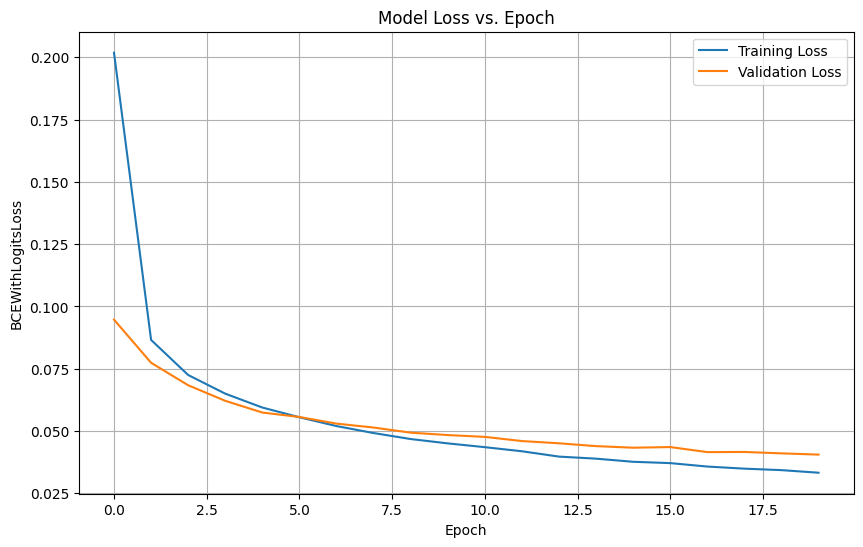

In [ ]:
# Plotting the loss history
plt.figure(figsize=(10, 6))
plt.plot(loss_history['train_loss'], label='Training Loss')
plt.plot(loss_history['val_loss'], label='Validation Loss')
plt.title('Model Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('BCEWithLogitsLoss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Saving the trained model to Drive
MODEL_SAVE_PATH = DRIVE_PATH + "mosquito_resnet50_v1.pth"
torch.save(trained_model.state_dict(), MODEL_SAVE_PATH)
print(f"Model saved successfully to: {MODEL_SAVE_PATH}")

Model saved successfully to: /content/drive/My Drive/MosquitoProject/mosquito_resnet50_v1.pth


In [ ]:
# Loading and Inspecting Glossary
GLOSSARY_PATH = DRIVE_PATH + "glossary.csv"

try:
    glossary_df = pd.read_csv(GLOSSARY_PATH)
    print("Glossary File Loaded")
    print(glossary_df.head())
    print("\nColumns:")
    print(glossary_df.columns.tolist())
except Exception as e:
    print(f"Error loading glossary: {e}")

Glossary File Loaded
  feature_id                                                  1  \
0    feat001  Abdominal segments with laterally projecting t...   
1    feat002  Hindtarsus with at least last 2 hindtarsomeres...   
2    feat003  Hindtarsomere 5 mainly or entirely dark, hindt...   
3    feat004                  Legs speckled, sometimes sparsely   
4    feat005  Wing entirely dark or with pale spots confined...   

                                                   0  
0  Abdominal segments not with laterally projecti...  
1  Hindtarsus with not at least last 2 hindtarsom...  
2  Hindtarsomere 5 not mainly or entirely dark wi...  
3              Legs not speckled, sometimes sparsely  
4  Wing not entirely dark or with pale spots conf...  

Columns:
['feature_id', '1', '0']


ENTOMOLOGIST REPORT
Image ID: 216

Observable Features:
• Abdominal segments not with laterally projecting tufts of scales on segments
  II-VII (96%)
• Hindtarsus with not at least last 2 hindtarsomeres entirely pale? (98%)
• Hindtarsomere 5 not mainly or entirely dark with hindtarsomere 4 white (100%)
• Wing not entirely dark or with pale spots confined to costa and vein 1 (100%)
• Wing without a pale spot on basal 0.5 of costa (94%)
• Maxillary palpus with apex pale (100%)
• Maxillary palpus with less than 4 pale bands (100%)
• 3rd main dark area without pale interruption (100%)
• Wing with I pale spot on upper branch of vein 5 (100%)
• Wing with abundant pale areas, costa with at least 4 pale spots (100%)


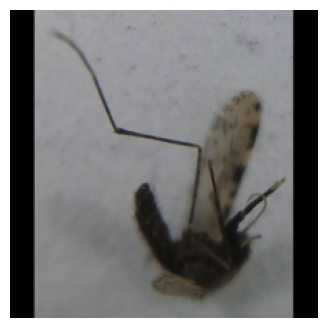

In [ ]:
import numpy as np
import textwrap

# Loading Glossary
# Making 'feature_id' the index to look up 'feat001' easily
glossary_df = pd.read_csv(DRIVE_PATH + "glossary.csv").set_index('feature_id')

def generate_mosquito_report(model, dataset, index=None):
    model.eval()
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # Picking an Image
    # If no index provided, pick a random one
    if index is None:
        index = np.random.randint(0, len(dataset))

    image, labels = dataset[index]

    # Preparing image for the model (adding batch dimension: [1, 3, 224, 224])
    image_input = image.unsqueeze(0).to(device)

    # Running the Model
    with torch.no_grad():
        outputs = model(image_input)
        # Applying Sigmoid to get probabilities (0.0 to 1.0)
        probs = torch.sigmoid(outputs).cpu().numpy()[0]

    # Generating the Report
    print(f"ENTOMOLOGIST REPORT")
    print(f"Image ID: {index}")

    # assuming the columns are ordered: feat001_checked, feat001_value, feat002_checked
    # looping through the glossary rows

    description_lines = []

    for i, feature_id in enumerate(glossary_df.index):
        # The 'value' probability is at odd indices: 1, 3, 5...
        # Index in output = (i * 2) + 1
        value_idx = (i * 2) + 1

        # checking to make sure we don't go out of bounds
        if value_idx >= len(probs):
            break

        prob = probs[value_idx]

        # The Translation Logic
        if prob > 0.5:
            text = glossary_df.loc[feature_id, '1']
            confidence = prob
        else:
            text = glossary_df.loc[feature_id, '0']
            confidence = 1.0 - prob

        # printing features where the model is confident (>75%) to keep it clean
        if confidence > 0.75:
            description_lines.append(f"• {text} ({confidence:.0%})")

    # Printing the top 10 most confident features
    print("\nObservable Features:")
    for line in description_lines[:10]:
        print(textwrap.fill(line, width=80, subsequent_indent='  '))

    # Showing the Image
    # un-normalizing the image to show it correctly
    img_display = image.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(img_display)
    plt.axis('off')
    plt.show()

# can run this multiple times to see different mosquitoes
generate_mosquito_report(trained_model, val_dataset)

In [ ]:
def calculate_accuracy(model, dataloader):
    model.eval()
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    total_features = 0
    correct_features = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Getting predictions
            outputs = model(inputs)
            preds = torch.sigmoid(outputs)

            # Rounding probabilities to 0 or 1 (threshold 0.5)
            predicted_labels = (preds > 0.5).float()

            # Comparing with true labels
            correct_features += (predicted_labels == labels).sum().item()
            total_features += labels.numel() # Total number of 1s and 0s in the batch

    accuracy = correct_features / total_features
    return accuracy

print("Calculating validation accuracy...")
val_acc = calculate_accuracy(trained_model, dataloaders['val'])
print(f"\nValidation Accuracy (Hamming): {val_acc:.2%}")

Calculating validation accuracy...

Validation Accuracy (Hamming): 98.53%


Running inference on validation set


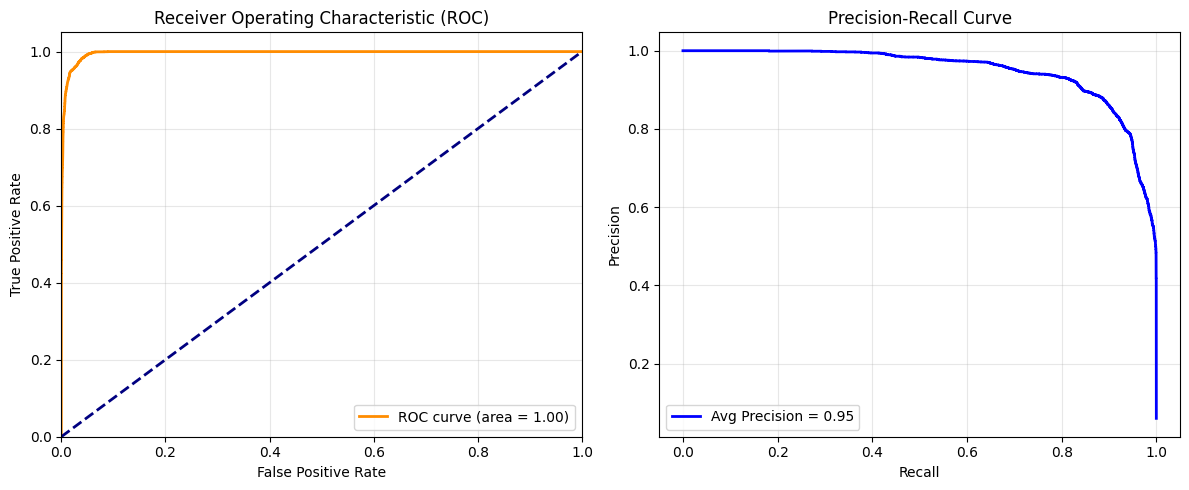

Plots generated. ROC AUC: 0.9963 | Avg Precision: 0.9494


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np

def plot_scientific_metrics(model, dataloader):
    model.eval()
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    all_labels = []
    all_preds = []

    print("Running inference on validation set")
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            preds = torch.sigmoid(outputs)

            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    # Concatenating all batches
    y_true = np.vstack(all_labels)
    y_score = np.vstack(all_preds)

    # Plotting ROC Curve
    # Micro-average aggregates the contributions of all classes
    fpr, tpr, _ = roc_curve(y_true.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(12, 5))

    # Subplot 1: ROC Curve
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    # Plotting Precision-Recall Curve (Micro-Average)
    precision, recall, _ = precision_recall_curve(y_true.ravel(), y_score.ravel())
    avg_precision = average_precision_score(y_true, y_score, average="micro")

    # Subplot 2: Precision-Recall
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='blue', lw=2, label=f'Avg Precision = {avg_precision:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Plots generated. ROC AUC: {roc_auc:.4f} | Avg Precision: {avg_precision:.4f}")

# Run it!
plot_scientific_metrics(trained_model, dataloaders['val'])

In [ ]:
from sklearn.metrics import confusion_matrix

def calculate_scalar_metrics(model, dataloader):
    model.eval()
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            preds = (torch.sigmoid(outputs) > 0.5).float() # Threshold at 0.5

            all_labels.append(labels.cpu().numpy().ravel()) # Flatten arrays
            all_preds.append(preds.cpu().numpy().ravel())

    # Concatenating
    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)

    # Calculating Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Calculating Metrics
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp)

    return sensitivity, specificity, accuracy, precision

sens, spec, acc, prec = calculate_scalar_metrics(trained_model, dataloaders['val'])

print(f"FINAL METRICS REPORT")
print(f"Sensitivity (Recall): {sens:.2%}")
print(f"Specificity:          {spec:.2%}")
print(f"Accuracy (Hamming):   {acc:.2%}")
print(f"Precision:            {prec:.2%}")

FINAL METRICS REPORT
Sensitivity (Recall): 83.59%
Specificity:          99.48%
Accuracy (Hamming):   98.53%
Precision:            91.15%


Gathering predictions for Confusion Matrix...


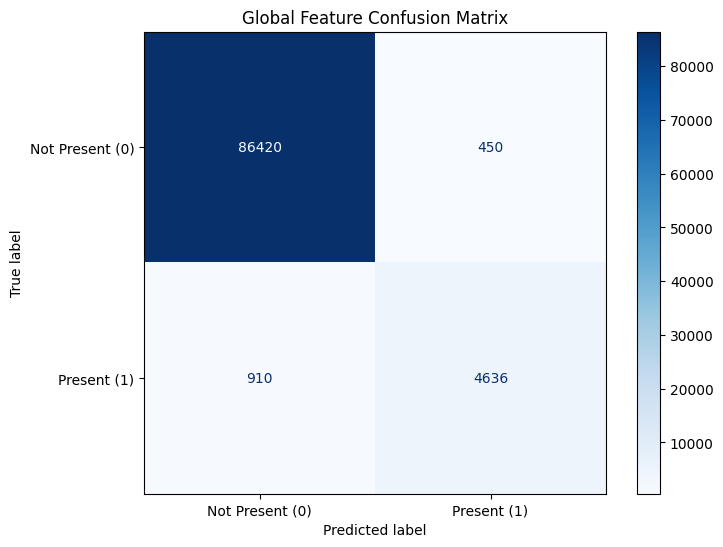

Correctly Identified Features (TP): 4636
Correctly Ignored (TN):           86420
Missed Features (FN):             910
Hallucinations (FP):              450


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_global_confusion_matrix(model, dataloader):
    model.eval()
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    all_labels = []
    all_preds = []

    print("Gathering predictions for Confusion Matrix...")

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            # Threshold at 0.5 to get 0s and 1s
            preds = (torch.sigmoid(outputs) > 0.5).float()

            # Flattening everything into one long list of 0s and 1s
            all_labels.append(labels.cpu().numpy().ravel())
            all_preds.append(preds.cpu().numpy().ravel())

    # Concatenating all batches
    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)

    # Generating Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plotting it
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Present (0)', 'Present (1)'])

    # Drawing nicely
    disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
    plt.title('Global Feature Confusion Matrix')
    plt.show()

    # Printing the raw numbers
    tn, fp, fn, tp = cm.ravel()
    print(f"Correctly Identified Features (TP): {tp}")
    print(f"Correctly Ignored (TN):           {tn}")
    print(f"Missed Features (FN):             {fn}")
    print(f"Hallucinations (FP):              {fp}")

# Running it
plot_global_confusion_matrix(trained_model, dataloaders['val'])

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

# Defining the Model Factory
def get_model(model_name, num_outputs):
    """
    Loads a pre-trained model and modifies the head for 256 outputs.
    Handles the different naming conventions of PyTorch models.
    """
    model = None

    if model_name == 'resnet50':
        model = models.resnet50(weights='DEFAULT')
        model.fc = nn.Linear(model.fc.in_features, num_outputs)

    elif model_name == 'mobilenet_v3':
        model = models.mobilenet_v3_large(weights='DEFAULT')
        # MobileNet's classifier is a sequence. The last layer is index 3.
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_outputs)

    elif model_name == 'efficientnet_b2':
        model = models.efficientnet_b2(weights='DEFAULT')
        # EfficientNet classifier[1] is the linear layer
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_outputs)

    elif model_name == 'convnext_tiny':
        model = models.convnext_tiny(weights='DEFAULT')
        # ConvNeXt classifier[2] is the linear layer
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_outputs)

    elif model_name == 'vit_b_16':
        model = models.vit_b_16(weights='DEFAULT')
        # ViT head is usually 'heads'
        in_features = model.heads.head.in_features
        model.heads.head = nn.Linear(in_features, num_outputs)

    return model

# The Benchmarking Loop
model_names = ['resnet50', 'mobilenet_v3', 'efficientnet_b2', 'convnext_tiny', 'vit_b_16']
trained_models = {}
num_outputs = len(full_dataset.feature_columns)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"Models: {model_names}")

for name in model_names:
    print(f"\nTraining {name}...")

    # Loading fresh model
    curr_model = get_model(name, num_outputs).to(device)

    # Defining Optimizer (fresh for each model)
    # We use a slightly lower LR for ViT and ConvNeXt to prevent instability
    lr = 0.0005 if name in ['vit_b_16', 'convnext_tiny'] else 0.001
    optimizer = optim.Adam(curr_model.parameters(), lr=lr)

    # Training (Using a smaller epoch count for speed, e.g., 10)
    curr_model, _ = train_model(curr_model, criterion, optimizer, num_epochs=30)

    # Storing for plotting
    trained_models[name] = curr_model

    torch.save(curr_model.state_dict(), DRIVE_PATH + f"model_{name}.pth")

print("\nAll 5 models trained successfully!")

Models: ['resnet50', 'mobilenet_v3', 'efficientnet_b2', 'convnext_tiny', 'vit_b_16']

Training resnet50...
Epoch 1/30
----------
train Loss: 0.0952
val Loss: 0.0733
Epoch 2/30
----------
train Loss: 0.0318
val Loss: 0.0494
Epoch 3/30
----------
train Loss: 0.0227
val Loss: 0.0374
Epoch 4/30
----------
train Loss: 0.0168
val Loss: 0.0757
Epoch 5/30
----------
train Loss: 0.0141
val Loss: 0.0464
Epoch 6/30
----------
train Loss: 0.0123
val Loss: 0.0264
Epoch 7/30
----------
train Loss: 0.0062
val Loss: 0.0408
Epoch 8/30
----------
train Loss: 0.0057
val Loss: 0.3142
Epoch 9/30
----------
train Loss: 0.0107
val Loss: 0.0521
Epoch 10/30
----------
train Loss: 0.0068
val Loss: 0.0371
Epoch 11/30
----------
train Loss: 0.0068
val Loss: 0.0671
Epoch 12/30
----------
train Loss: 0.0074
val Loss: 0.1569
Epoch 13/30
----------
train Loss: 0.0096
val Loss: 0.0234
Epoch 14/30
----------
train Loss: 0.0023
val Loss: 0.0281
Epoch 15/30
----------
train Loss: 0.0034
val Loss: 0.0383
Epoch 16/30
-----

100%|██████████| 21.1M/21.1M [00:00<00:00, 186MB/s]


Epoch 1/30
----------
train Loss: 0.0954
val Loss: 0.2950
Epoch 2/30
----------
train Loss: 0.0268
val Loss: 0.0785
Epoch 3/30
----------
train Loss: 0.0142
val Loss: 0.0557
Epoch 4/30
----------
train Loss: 0.0122
val Loss: 0.1015
Epoch 5/30
----------
train Loss: 0.0090
val Loss: 0.0627
Epoch 6/30
----------
train Loss: 0.0087
val Loss: 0.0787
Epoch 7/30
----------
train Loss: 0.0077
val Loss: 0.0531
Epoch 8/30
----------
train Loss: 0.0064
val Loss: 0.0883
Epoch 9/30
----------
train Loss: 0.0039
val Loss: 0.0368
Epoch 10/30
----------
train Loss: 0.0061
val Loss: 0.0629
Epoch 11/30
----------
train Loss: 0.0044
val Loss: 0.0801
Epoch 12/30
----------
train Loss: 0.0050
val Loss: 0.0452
Epoch 13/30
----------
train Loss: 0.0046
val Loss: 0.0212
Epoch 14/30
----------
train Loss: 0.0029
val Loss: 0.0507
Epoch 15/30
----------
train Loss: 0.0037
val Loss: 0.0499
Epoch 16/30
----------
train Loss: 0.0046
val Loss: 0.0500
Epoch 17/30
----------
train Loss: 0.0034
val Loss: 0.0526
Epoch 

100%|██████████| 35.2M/35.2M [00:00<00:00, 211MB/s]


Epoch 1/30
----------
train Loss: 0.1114
val Loss: 0.0272
Epoch 2/30
----------
train Loss: 0.0255
val Loss: 0.0240
Epoch 3/30
----------
train Loss: 0.0185
val Loss: 0.0350
Epoch 4/30
----------
train Loss: 0.0126
val Loss: 0.0191
Epoch 5/30
----------
train Loss: 0.0088
val Loss: 0.0165
Epoch 6/30
----------
train Loss: 0.0080
val Loss: 0.0247
Epoch 7/30
----------
train Loss: 0.0082
val Loss: 0.0176
Epoch 8/30
----------
train Loss: 0.0054
val Loss: 0.0349
Epoch 9/30
----------
train Loss: 0.0087
val Loss: 0.0293
Epoch 10/30
----------
train Loss: 0.0067
val Loss: 0.0296
Epoch 11/30
----------
train Loss: 0.0072
val Loss: 0.0317
Epoch 12/30
----------
train Loss: 0.0055
val Loss: 0.0163
Epoch 13/30
----------
train Loss: 0.0030
val Loss: 0.0218
Epoch 14/30
----------
train Loss: 0.0037
val Loss: 0.0241
Epoch 15/30
----------
train Loss: 0.0023
val Loss: 0.0209
Epoch 16/30
----------
train Loss: 0.0020
val Loss: 0.0202
Epoch 17/30
----------
train Loss: 0.0018
val Loss: 0.0275
Epoch 

100%|██████████| 109M/109M [00:00<00:00, 167MB/s] 


Epoch 1/30
----------
train Loss: 0.1473
val Loss: 0.0695
Epoch 2/30
----------
train Loss: 0.0551
val Loss: 0.0401
Epoch 3/30
----------
train Loss: 0.0267
val Loss: 0.0491
Epoch 4/30
----------
train Loss: 0.0228
val Loss: 0.0254
Epoch 5/30
----------
train Loss: 0.0154
val Loss: 0.0278
Epoch 6/30
----------
train Loss: 0.0149
val Loss: 0.0388
Epoch 7/30
----------
train Loss: 0.0066
val Loss: 0.0300
Epoch 8/30
----------
train Loss: 0.0080
val Loss: 0.0275
Epoch 9/30
----------
train Loss: 0.0109
val Loss: 0.0232
Epoch 10/30
----------
train Loss: 0.0073
val Loss: 0.0246
Epoch 11/30
----------
train Loss: 0.0036
val Loss: 0.0307
Epoch 12/30
----------
train Loss: 0.0058
val Loss: 0.0315
Epoch 13/30
----------
train Loss: 0.0028
val Loss: 0.0258
Epoch 14/30
----------
train Loss: 0.0015
val Loss: 0.0309
Epoch 15/30
----------
train Loss: 0.0008
val Loss: 0.0286
Epoch 16/30
----------
train Loss: 0.0009
val Loss: 0.0229
Epoch 17/30
----------
train Loss: 0.0006
val Loss: 0.0502
Epoch 

100%|██████████| 330M/330M [00:02<00:00, 146MB/s]


Epoch 1/30
----------
train Loss: 0.1578
val Loss: 0.1007
Epoch 2/30
----------
train Loss: 0.0997
val Loss: 0.0996
Epoch 3/30
----------
train Loss: 0.0978
val Loss: 0.0965
Epoch 4/30
----------
train Loss: 0.0937
val Loss: 0.0927
Epoch 5/30
----------
train Loss: 0.0879
val Loss: 0.0884
Epoch 6/30
----------
train Loss: 0.0851
val Loss: 0.0855
Epoch 7/30
----------
train Loss: 0.0832
val Loss: 0.0872
Epoch 8/30
----------
train Loss: 0.0828
val Loss: 0.0800
Epoch 9/30
----------
train Loss: 0.0769
val Loss: 0.0828
Epoch 10/30
----------
train Loss: 0.0778
val Loss: 0.0756
Epoch 11/30
----------
train Loss: 0.0714
val Loss: 0.0833
Epoch 12/30
----------
train Loss: 0.0659
val Loss: 0.0720
Epoch 13/30
----------
train Loss: 0.0618
val Loss: 0.0629
Epoch 14/30
----------
train Loss: 0.0582
val Loss: 0.0677
Epoch 15/30
----------
train Loss: 0.0576
val Loss: 0.0632
Epoch 16/30
----------
train Loss: 0.0524
val Loss: 0.0655
Epoch 17/30
----------
train Loss: 0.0544
val Loss: 0.0833
Epoch 

Evaluating resnet50...
Evaluating mobilenet_v3...
Evaluating efficientnet_b2...
Evaluating convnext_tiny...
Evaluating vit_b_16...


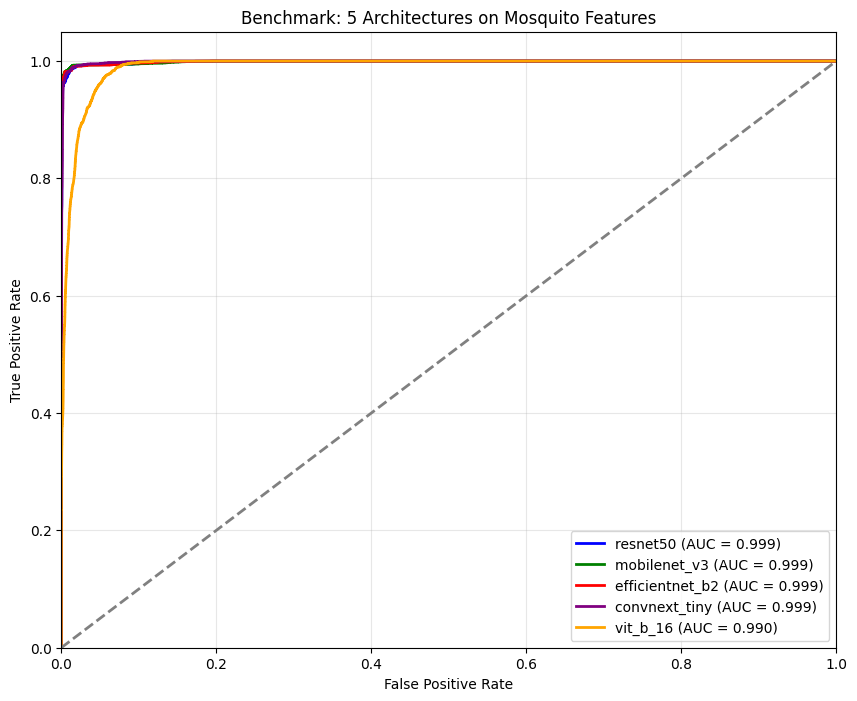

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_benchmark_results(models_dict, dataloader):
    plt.figure(figsize=(10, 8))
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    colors = ['blue', 'green', 'red', 'purple', 'orange']

    for (name, model), color in zip(models_dict.items(), colors):
        print(f"Evaluating {name}...")
        model.eval()

        all_labels = []
        all_preds = []

        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)
                preds = torch.sigmoid(outputs)
                all_labels.append(labels.cpu().numpy().ravel())
                all_preds.append(preds.cpu().numpy().ravel())

        y_true = np.concatenate(all_labels)
        y_score = np.concatenate(all_preds)

        # Calculating ROC
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        # Plotting Line
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

    # Plotting Diagonal
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

    # Formatting
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Benchmark: 5 Architectures on Mosquito Features')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_benchmark_results(trained_models, dataloaders['val'])

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix

def get_metrics_for_model(model, dataloader):
    model.eval()
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            all_labels.append(labels.cpu().numpy().ravel())
            all_preds.append(preds.cpu().numpy().ravel())

    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Sensitivity (Recall)": tp / (tp + fn),
        "Specificity": tn / (tn + fp),
        "Accuracy (Hamming)": (tp + tn) / (tp + tn + fp + fn),
        "Precision": tp / (tp + fp)
    }

# Running for ALL models
results_list = []

print("Calculatng metrics for all models...")
# 'trained_models' is the dictionary we created
for model_name, model_obj in trained_models.items():
    print(f"  ...evaluating {model_name}")
    metrics = get_metrics_for_model(model_obj, dataloaders['val'])
    metrics["Model"] = model_name
    results_list.append(metrics)

# Creating the Leaderboard
leaderboard_df = pd.DataFrame(results_list)
# Reordering columns to put Model first
leaderboard_df = leaderboard_df[["Model", "Accuracy (Hamming)", "Sensitivity (Recall)", "Specificity", "Precision"]]
# Sorting by Accuracy
leaderboard_df = leaderboard_df.sort_values(by="Accuracy (Hamming)", ascending=False)

# Display nicely
display(leaderboard_df.style.format({
    "Accuracy (Hamming)": "{:.2%}",
    "Sensitivity (Recall)": "{:.2%}",
    "Specificity": "{:.2%}",
    "Precision": "{:.2%}"
}).background_gradient(cmap='Blues'))

Calculatng metrics for all models...
  ...evaluating resnet50
  ...evaluating mobilenet_v3
  ...evaluating efficientnet_b2
  ...evaluating convnext_tiny
  ...evaluating vit_b_16


,Model,Accuracy (Hamming),Sensitivity (Recall),Specificity,Precision
1,mobilenet_v3,99.65%,96.68%,99.84%,97.42%
2,efficientnet_b2,99.56%,95.98%,99.79%,96.62%
3,convnext_tiny,99.55%,96.23%,99.77%,96.34%
0,resnet50,99.54%,95.55%,99.80%,96.82%
4,vit_b_16,97.41%,76.60%,98.74%,79.55%


Generating Confusion Matrix Grid...


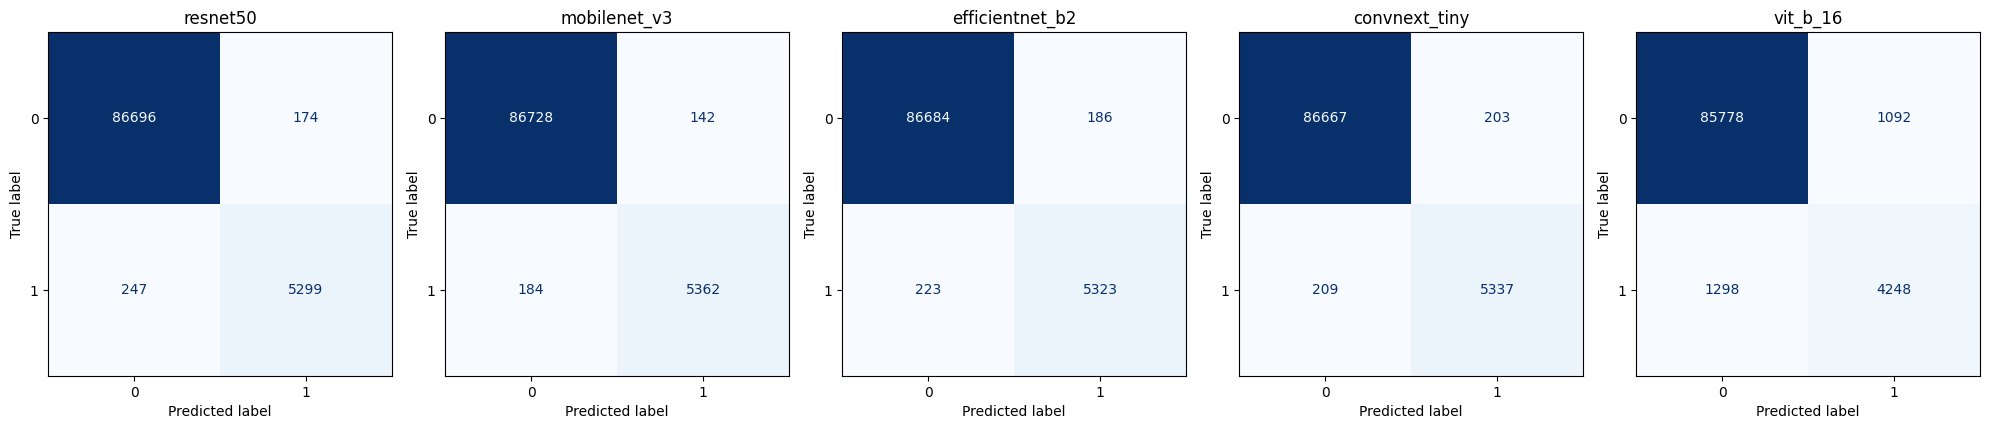

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_all_confusion_matrices(models_dict, dataloader):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    num_models = len(models_dict)
    # Creating a row of subplots
    fig, axes = plt.subplots(1, num_models, figsize=(4 * num_models, 4))

    if num_models == 1: axes = [axes] # Handle single model case

    for ax, (model_name, model_obj) in zip(axes, models_dict.items()):
        model_obj.eval()
        all_labels = []
        all_preds = []

        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model_obj(inputs)
                preds = (torch.sigmoid(outputs) > 0.5).float()
                all_labels.append(labels.cpu().numpy().ravel())
                all_preds.append(preds.cpu().numpy().ravel())

        y_true = np.concatenate(all_labels)
        y_pred = np.concatenate(all_preds)
        cm = confusion_matrix(y_true, y_pred)

        # Plot
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
        disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
        ax.set_title(f"{model_name}")
        ax.grid(False) # Turning off grid lines for cleaner look

    plt.tight_layout()
    plt.show()

print("Generating Confusion Matrix Grid...")
plot_all_confusion_matrices(trained_models, dataloaders['val'])


TARGET MOSQUITO (Image ID: 124)


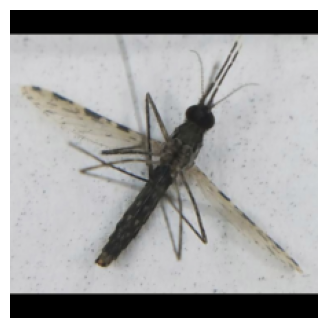

  • Legs speckled, sometimes sparsely
  • Legs speckled
  • 3rd main dark area of wing vein 1 with a pale interruption, sometimes fused with preceding pale spot; scaling on abdomen very scanty, confined to tergum VIII or rarely VII
  • 3rd main dark area of vein 1 with a pale interruption, sometimes fused with preceding pale area
------------------------------------------------------------

RESNET50 SEES:
  correct [100%] Legs speckled, sometimes sparsely
  correct [100%] Legs speckled
  correct [100%] 3rd main dark area of wing vein 1 with a pale interruption, sometimes fused with preceding pale spot; scaling on abdomen very scanty, confined to tergum VIII or rarely VII
  correct [100%] 3rd main dark area of vein 1 with a pale interruption, sometimes fused with preceding pale area

MOBILENET_V3 SEES:
  correct [100%] Legs speckled, sometimes sparsely
  correct [100%] Legs speckled
  correct [100%] 3rd main dark area of wing vein 1 with a pale interruption, sometimes fused with precedi

In [ ]:
import textwrap

def compare_model_narratives(models_dict, dataset, glossary_df, index=None):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # Picking one image to look at
    if index is None:
        index = np.random.randint(0, len(dataset))

    image, true_labels = dataset[index]
    image_input = image.unsqueeze(0).to(device)

    # Displaying the Image
    print(f"\nTARGET MOSQUITO (Image ID: {index})")
    img_display = image.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(img_display)
    plt.axis('off')
    plt.show()

    true_features = []
    for i, feature_id in enumerate(glossary_df.index):
        # Checking the 'Value' column (odd indices in the label vector)
        val_idx = (i * 2) + 1
        if val_idx < len(true_labels) and true_labels[val_idx] == 1:
            text = glossary_df.loc[feature_id, '1']
            true_features.append(text)

    for feat in true_features[:5]: # Printing top 5
        print(f"  • {feat}")
    if len(true_features) > 5: print("  ... (and more)")

    print("-" * 60)

    # Running Every Model
    for model_name, model in models_dict.items():
        model.eval()
        with torch.no_grad():
            outputs = model(image_input)
            probs = torch.sigmoid(outputs).cpu().numpy()[0]

        print(f"\n{model_name.upper()} SEES:")

        found_features = []
        for i, feature_id in enumerate(glossary_df.index):
            val_idx = (i * 2) + 1
            if val_idx >= len(probs): break

            prob = probs[val_idx]
            text = glossary_df.loc[feature_id, '1']

            # Threshold > 0.5 to count as "seen"
            if prob > 0.5:
                # Adding confidence score
                found_features.append((prob, text))

        # Sorting by confidence (highest first)
        found_features.sort(key=lambda x: x[0], reverse=True)

        if not found_features:
            print("  (No features detected with >50% confidence)")
        else:
            for prob, text in found_features[:5]: # Top 5
                # Checking if it was in Ground Truth (Correct vs Hallucination)
                is_correct = "correct" if text in true_features else "incorrect"
                print(f"  {is_correct} [{prob:.0%}] {text}")

# Running the comparison
# Passing the dictionary of trained models
compare_model_narratives(trained_models, val_dataset, glossary_df)